In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned datasets
customers = pd.read_csv("../data/cleaned/customers_cleaned.csv")
orders = pd.read_csv("../data/cleaned/orders_cleaned.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [2]:
print("CUSTOMERS COLUMNS:")
print(customers.columns.tolist())

print("\nORDERS COLUMNS:")
print(orders.columns.tolist())

print("\nCustomers Shape:", customers.shape)
print("Orders Shape:", orders.shape)

CUSTOMERS COLUMNS:
['customer_id', 'customer_name', 'gender', 'age', 'city', 'state', 'signup_date', 'acquisition_channel', 'customer_segment']

ORDERS COLUMNS:
['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount_percent', 'payment_method', 'order_status']

Customers Shape: (10000, 9)
Orders Shape: (60000, 9)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert order date
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Create revenue column
orders["gross_revenue"] = orders["quantity"] * orders["unit_price"]

orders["discount_amount"] = (
    orders["gross_revenue"] * orders["discount_percent"] / 100
)

orders["net_revenue"] = (
    orders["gross_revenue"] - orders["discount_amount"]
)

# Merge customers with orders
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

print("Customer orders dataset created successfully!")
print(customer_orders.shape)

Customer orders dataset created successfully!
(60000, 20)


In [4]:
customer_analysis = customer_orders.groupby("customer_id").agg(
    total_orders=("order_id", "count"),
    total_quantity=("quantity", "sum"),
    total_revenue=("net_revenue", "sum"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max")
).reset_index()

customer_analysis.head()

,customer_id,total_orders,total_quantity,total_revenue,first_order,last_order
0,C100000,7,15,63605.2210,2025-04-25,2026-07-25
1,C100001,8,22,90715.1785,2025-01-27,2026-03-06
2,C100002,4,8,30120.4630,2025-11-29,2026-08-05
3,C100003,8,21,93436.8960,2025-01-02,2026-06-30
4,C100004,9,24,66357.8590,2025-01-13,2026-06-27


In [5]:
print("CUSTOMER PURCHASE ANALYSIS")
print("=" * 50)

print("Average Orders per Customer:",
      round(customer_analysis["total_orders"].mean(), 2))

print("Maximum Orders by a Customer:",
      customer_analysis["total_orders"].max())

print("Average Customer Revenue: ₹",
      round(customer_analysis["total_revenue"].mean(), 2))

CUSTOMER PURCHASE ANALYSIS
Average Orders per Customer: 6.01
Maximum Orders by a Customer: 18
Average Customer Revenue: ₹ 50485.67


In [6]:
top_customers = customer_analysis.sort_values(
    "total_revenue",
    ascending=False
).head(10)

print("TOP 10 CUSTOMERS BY REVENUE")

top_customers[[
    "customer_id",
    "total_orders",
    "total_revenue"
]]

TOP 10 CUSTOMERS BY REVENUE


,customer_id,total_orders,total_revenue
4258,C104269,14,173304.8615
2215,C102222,12,168634.7970
6225,C106239,15,163890.5360
7617,C107634,16,160812.6680
2883,C102891,12,160135.4510
6828,C106843,12,159644.5620
917,C100924,10,152748.7790
6069,C106083,16,151644.0085
5573,C105586,18,149049.5070
4078,C104089,14,147690.6165


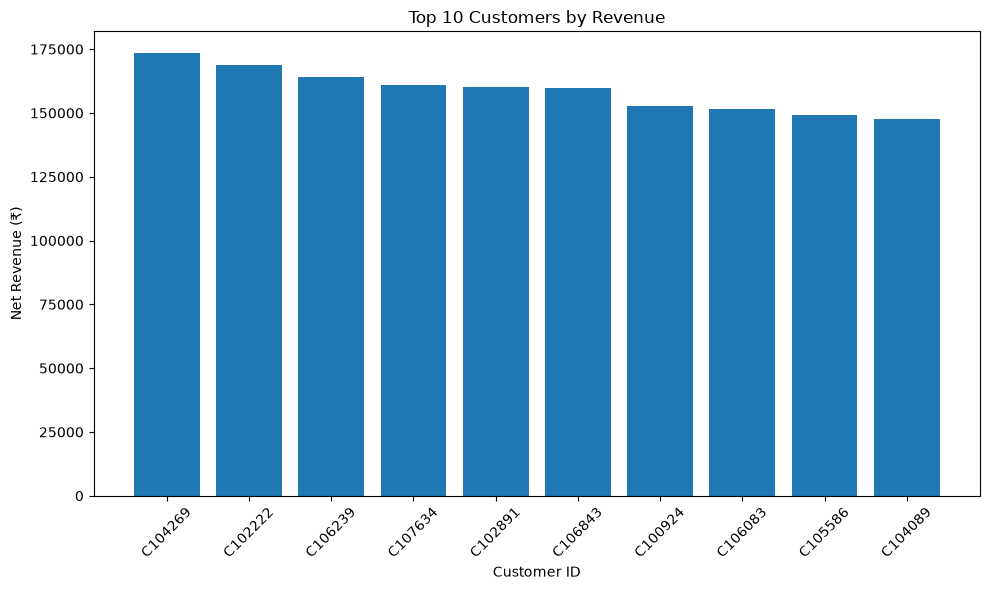

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["customer_id"],
    top_customers["total_revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Net Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# Find the latest order date in the dataset
reference_date = orders["order_date"].max() + pd.Timedelta(days=1)

# Create RFM metrics
rfm = customer_orders.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (reference_date - x.max()).days),
    Frequency=("order_id", "count"),
    Monetary=("net_revenue", "sum")
).reset_index()

print("RFM Analysis Created Successfully!")
print("Reference Date:", reference_date)

rfm.head()

RFM Analysis Created Successfully!
Reference Date: 2026-08-09 00:00:00


,customer_id,Recency,Frequency,Monetary
0,C100000,15,7,63605.2210
1,C100001,156,8,90715.1785
2,C100002,4,4,30120.4630
3,C100003,40,8,93436.8960
4,C100004,43,9,66357.8590


In [9]:
# Recency Score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=4,
    labels=[4, 3, 2, 1],
    duplicates="drop"
)

# Frequency Score
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
    duplicates="drop"
)

# Monetary Score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=4,
    labels=[1, 2, 3, 4],
    duplicates="drop"
)

# Convert scores to integer
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

# Total RFM Score
rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,C100000,15,7,63605.2210,4,3,3,10
1,C100001,156,8,90715.1785,1,3,4,8
2,C100002,4,4,30120.4630,4,1,1,6
3,C100003,40,8,93436.8960,3,3,4,10
4,C100004,43,9,66357.8590,3,4,4,11


In [10]:
def customer_segment(row):
    
    if row["R_Score"] >= 3 and row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Champions"
    
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"
    
    elif row["R_Score"] >= 3 and row["F_Score"] <= 2:
        return "Potential Loyalists"
    
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "At Risk"
    
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost Customers"
    
    else:
        return "Regular Customers"


rfm["Customer_Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

print("Customer Segmentation Completed Successfully!")

rfm.head(10)


Customer Segmentation Completed Successfully!


,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,C100000,15,7,63605.2210,4,3,3,10,Champions
1,C100001,156,8,90715.1785,1,3,4,8,At Risk
2,C100002,4,4,30120.4630,4,1,1,6,Potential Loyalists
3,C100003,40,8,93436.8960,3,3,4,10,Champions
4,C100004,43,9,66357.8590,3,4,4,11,Champions
5,C100005,318,4,19559.8300,1,1,1,3,Lost Customers
6,C100006,121,4,16451.1590,2,1,1,4,Lost Customers
7,C100007,99,5,33247.8470,2,2,2,6,Lost Customers
8,C100008,114,3,34078.8060,2,1,2,5,Lost Customers
9,C100009,46,5,51490.0550,3,2,3,8,Potential Loyalists


In [11]:
segment_summary = rfm.groupby("Customer_Segment").agg(
    Total_Customers=("customer_id", "count"),
    Average_Revenue=("Monetary", "mean"),
    Average_Orders=("Frequency", "mean"),
    Average_Recency=("Recency", "mean")
).sort_values(
    "Total_Customers",
    ascending=False
)

segment_summary

,Total_Customers,Average_Revenue,Average_Orders,Average_Recency
Customer_Segment,,,,
Lost Customers,3036,32690.577412,3.900527,184.557971
Champions,2442,74887.844748,8.404996,28.769042
Potential Loyalists,1952,37447.181825,4.432377,31.226947
At Risk,1467,72734.068843,7.945467,124.436946
Loyal Customers,606,38630.248133,6.869637,29.808581
Regular Customers,473,38715.972246,6.684989,137.471459


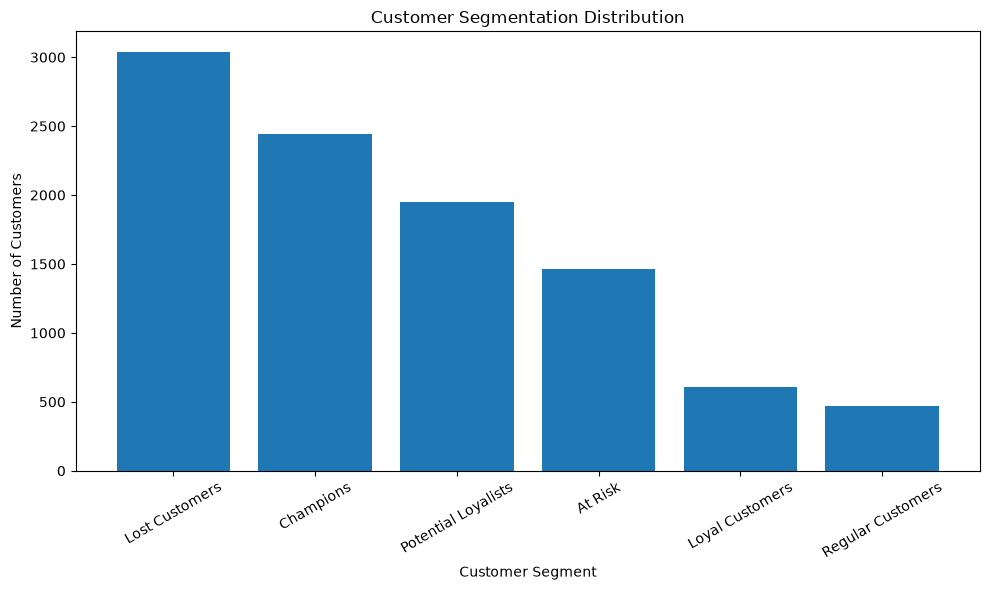

Customer_Segment
Lost Customers         3036
Champions              2442
Potential Loyalists    1952
At Risk                1467
Loyal Customers         606
Regular Customers       473
Name: count, dtype: int64


In [12]:
segment_counts = rfm["Customer_Segment"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print(segment_counts)

In [13]:
segment_revenue = rfm.groupby("Customer_Segment").agg(
    Total_Customers=("customer_id", "count"),
    Total_Revenue=("Monetary", "sum"),
    Average_Revenue=("Monetary", "mean")
).sort_values(
    "Total_Revenue",
    ascending=False
)

# Calculate revenue contribution percentage
segment_revenue["Revenue_Contribution_%"] = (
    segment_revenue["Total_Revenue"]
    / segment_revenue["Total_Revenue"].sum()
) * 100

segment_revenue = segment_revenue.round(2)

print("REVENUE CONTRIBUTION BY CUSTOMER SEGMENT")
print("=" * 60)

segment_revenue

REVENUE CONTRIBUTION BY CUSTOMER SEGMENT


,Total_Customers,Total_Revenue,Average_Revenue,Revenue_Contribution_%
Customer_Segment,,,,
Champions,2442,1.828761e+08,74887.84,36.31
At Risk,1467,1.067009e+08,72734.07,21.19
Lost Customers,3036,9.924859e+07,32690.58,19.71
Potential Loyalists,1952,7.309690e+07,37447.18,14.51
Loyal Customers,606,2.340993e+07,38630.25,4.65
Regular Customers,473,1.831265e+07,38715.97,3.64


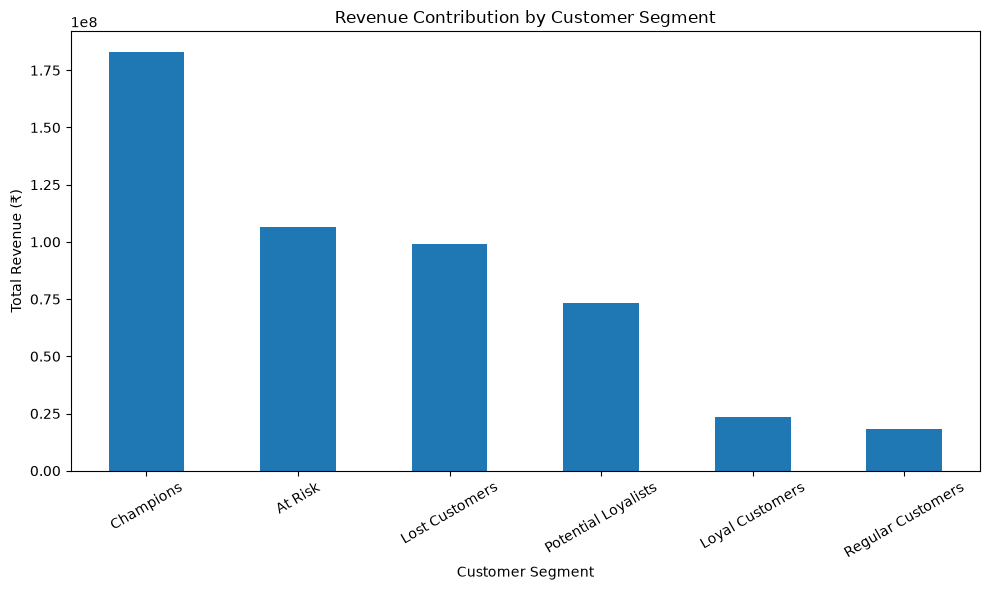

In [14]:
plt.figure(figsize=(10, 6))

segment_revenue["Total_Revenue"].plot(
    kind="bar"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [15]:
at_risk_customers = rfm[
    rfm["Customer_Segment"] == "At Risk"
].sort_values(
    "Monetary",
    ascending=False
)

print("HIGH-VALUE CUSTOMERS AT RISK")
print("=" * 60)

at_risk_customers.head(10)

HIGH-VALUE CUSTOMERS AT RISK


,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
6225,C106239,68,15,163890.5360,2,4,4,10,At Risk
6069,C106083,68,16,151644.0085,2,4,4,10,At Risk
6329,C106344,78,15,143105.4670,2,4,4,10,At Risk
3147,C103155,82,14,141908.9185,2,4,4,10,At Risk
4305,C104316,85,10,136382.9210,2,4,4,10,At Risk
5587,C105600,90,11,136362.0835,2,4,4,10,At Risk
2813,C102821,133,12,134011.5770,2,4,4,10,At Risk
7442,C107459,69,11,133721.9800,2,4,4,10,At Risk
275,C100277,74,9,132386.3260,2,4,4,10,At Risk
2667,C102675,74,11,131956.4910,2,4,4,10,At Risk


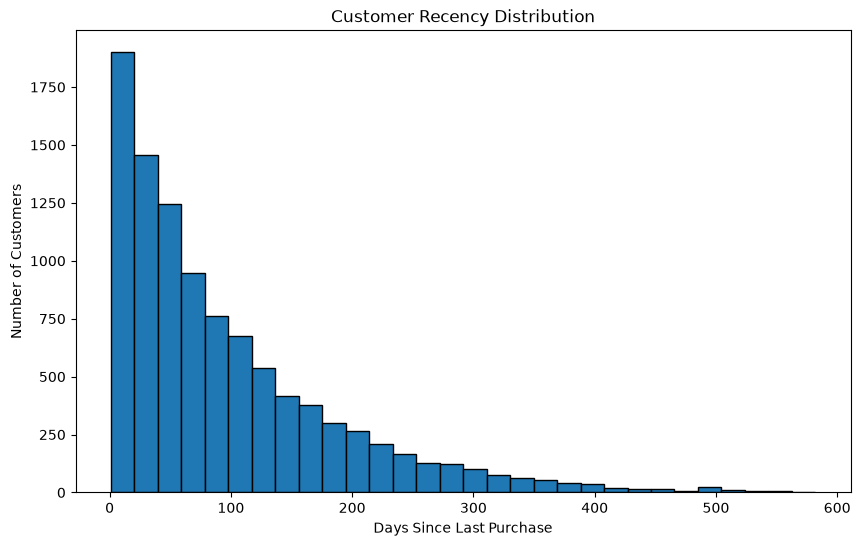

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    rfm["Recency"],
    bins=30,
    edgecolor="black"
)

plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
def churn_status(recency):
    
    if recency <= 30:
        return "Active"
    
    elif recency <= 90:
        return "At Risk"
    
    else:
        return "Churned"


rfm["Churn_Status"] = rfm["Recency"].apply(churn_status)

print("Churn status created successfully!")

churn_summary = rfm.groupby("Churn_Status").agg(
    Total_Customers=("customer_id", "count"),
    Average_Revenue=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
)

churn_summary

Churn status created successfully!


,Total_Customers,Average_Revenue,Total_Revenue
Churn_Status,,,
Active,2695,57446.753950,1.548190e+08
At Risk,3359,53865.862848,1.809354e+08
Churned,3922,42807.403837,1.678906e+08


In [18]:
total_customers = rfm["customer_id"].nunique()

churned_customers = (
    rfm[rfm["Churn_Status"] == "Churned"]["customer_id"]
    .nunique()
)

at_risk_customers = (
    rfm[rfm["Churn_Status"] == "At Risk"]["customer_id"]
    .nunique()
)

churn_rate = (churned_customers / total_customers) * 100

at_risk_rate = (at_risk_customers / total_customers) * 100

print("CUSTOMER RETENTION & CHURN METRICS")
print("=" * 50)

print(f"Total Customers: {total_customers:,}")
print(f"Active Customers: {2695:,}")
print(f"At-Risk Customers: {at_risk_customers:,}")
print(f"Churned Customers: {churned_customers:,}")

print("-" * 50)

print(f"At-Risk Rate: {at_risk_rate:.2f}%")
print(f"Churn Rate: {churn_rate:.2f}%")

CUSTOMER RETENTION & CHURN METRICS
Total Customers: 9,976
Active Customers: 2,695
At-Risk Customers: 3,359
Churned Customers: 3,922
--------------------------------------------------
At-Risk Rate: 33.67%
Churn Rate: 39.31%


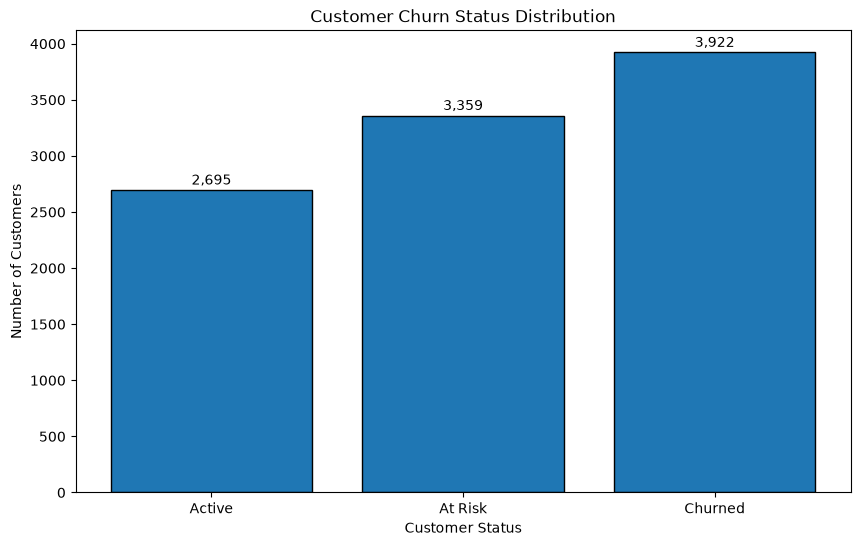

In [19]:
import matplotlib.pyplot as plt

churn_counts = (
    rfm["Churn_Status"]
    .value_counts()
    .reindex(["Active", "At Risk", "Churned"])
)

plt.figure(figsize=(10, 6))

plt.bar(
    churn_counts.index,
    churn_counts.values,
    edgecolor="black"
)

plt.title("Customer Churn Status Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Add customer count labels
for i, value in enumerate(churn_counts.values):
    plt.text(
        i,
        value + 50,
        f"{value:,}",
        ha="center"
    )

plt.show()

In [20]:
revenue_by_churn = (
    rfm.groupby("Churn_Status")
    .agg(
        Total_Customers=("customer_id", "count"),
        Total_Revenue=("Monetary", "sum"),
        Average_Revenue=("Monetary", "mean")
    )
    .reindex(["Active", "At Risk", "Churned"])
)

# Calculate revenue contribution percentage
total_revenue = revenue_by_churn["Total_Revenue"].sum()

revenue_by_churn["Revenue_Contribution_%"] = (
    revenue_by_churn["Total_Revenue"] / total_revenue
) * 100

print("REVENUE BY CUSTOMER CHURN STATUS")
print("=" * 70)

revenue_by_churn

REVENUE BY CUSTOMER CHURN STATUS


,Total_Customers,Total_Revenue,Average_Revenue,Revenue_Contribution_%
Churn_Status,,,,
Active,2695,1.548190e+08,57446.753950,30.739703
At Risk,3359,1.809354e+08,53865.862848,35.925187
Churned,3922,1.678906e+08,42807.403837,33.335110


In [21]:
revenue_at_risk = revenue_by_churn.loc["At Risk", "Total_Revenue"]

churned_revenue = revenue_by_churn.loc["Churned", "Total_Revenue"]

total_risk_revenue = revenue_at_risk + churned_revenue

print("REVENUE RISK ANALYSIS")
print("=" * 50)

print(f"Revenue from Active Customers: ₹{revenue_by_churn.loc['Active', 'Total_Revenue']:,.2f}")

print(f"Revenue at Risk: ₹{revenue_at_risk:,.2f}")

print(f"Revenue from Churned Customers: ₹{churned_revenue:,.2f}")

print("-" * 50)

print(f"Total Revenue Impact: ₹{total_risk_revenue:,.2f}")

REVENUE RISK ANALYSIS
Revenue from Active Customers: ₹154,819,001.90
Revenue at Risk: ₹180,935,433.31
Revenue from Churned Customers: ₹167,890,637.85
--------------------------------------------------
Total Revenue Impact: ₹348,826,071.15


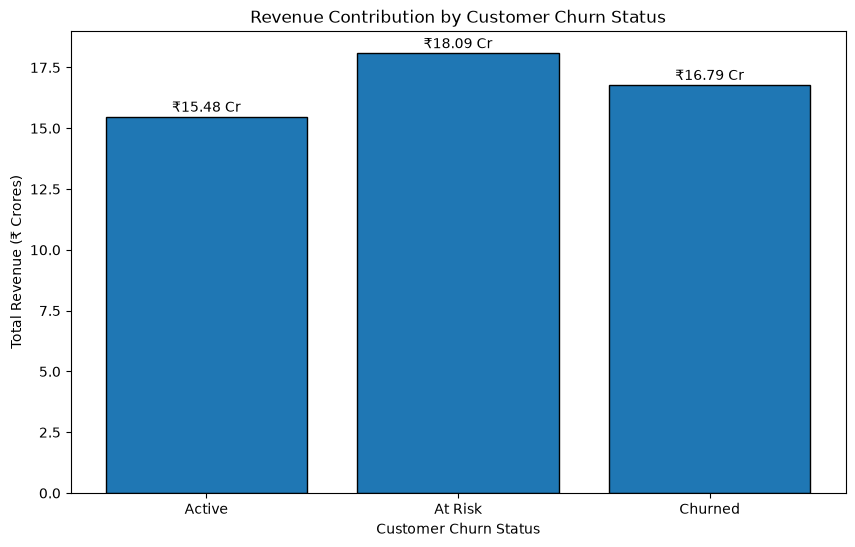

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    revenue_by_churn.index,
    revenue_by_churn["Total_Revenue"] / 1e7,
    edgecolor="black"
)

plt.title("Revenue Contribution by Customer Churn Status")
plt.xlabel("Customer Churn Status")
plt.ylabel("Total Revenue (₹ Crores)")

# Add revenue labels
for i, value in enumerate(revenue_by_churn["Total_Revenue"] / 1e7):
    plt.text(
        i,
        value + 0.2,
        f"₹{value:.2f} Cr",
        ha="center"
    )

plt.show()

In [23]:
# Merge customer information with RFM analysis

customer_quality = customers.merge(
    rfm[
        [
            "customer_id",
            "Monetary",
            "Customer_Segment",
            "Churn_Status"
        ]
    ],
    on="customer_id",
    how="inner"
)

print("Customer Quality Dataset Created Successfully!")

customer_quality.head()

Customer Quality Dataset Created Successfully!


,customer_id,customer_name,gender,age,city,state,signup_date,acquisition_channel,customer_segment,Monetary,Customer_Segment,Churn_Status
0,C100000,Sai Kumar,Female,61.0,Delhi,Delhi,2024-03-06,YouTube,Premium,63605.2210,Champions,Active
1,C100001,Aditya Patel,Female,53.0,Mumbai,Maharashtra,2025-07-18,YouTube,Premium,90715.1785,At Risk,Churned
2,C100002,Rohan Sharma,Male,27.0,Pune,Maharashtra,2025-04-22,Organic Search,Standard,30120.4630,Potential Loyalists,Active
3,C100003,Sai Naidu,Male,65.0,Kolkata,West Bengal,2024-11-16,Google Ads,Basic,93436.8960,Champions,At Risk
4,C100004,Arjun Varma,Male,65.0,Mumbai,Maharashtra,2024-11-12,Referral,Standard,66357.8590,Champions,At Risk


In [24]:
channel_quality = customer_quality.groupby(
    "acquisition_channel"
).agg(
    Total_Customers=("customer_id", "count"),
    Total_Revenue=("Monetary", "sum"),
    Average_Customer_Value=("Monetary", "mean")
)

channel_quality["Churned_Customers"] = (
    customer_quality[
        customer_quality["Churn_Status"] == "Churned"
    ]
    .groupby("acquisition_channel")["customer_id"]
    .count()
)

channel_quality["Champions"] = (
    customer_quality[
        customer_quality["Customer_Segment"] == "Champions"
    ]
    .groupby("acquisition_channel")["customer_id"]
    .count()
)

channel_quality["Churn_Rate_%"] = (
    channel_quality["Churned_Customers"]
    / channel_quality["Total_Customers"]
) * 100

channel_quality = channel_quality.sort_values(
    "Total_Revenue",
    ascending=False
)

print("ACQUISITION CHANNEL vs CUSTOMER QUALITY")
print("=" * 80)

channel_quality

ACQUISITION CHANNEL vs CUSTOMER QUALITY


,Total_Customers,Total_Revenue,Average_Customer_Value,Churned_Customers,Champions,Churn_Rate_%
acquisition_channel,,,,,,
Google Ads,2364,1.182485e+08,50020.520764,953,562,40.313029
Instagram,2184,1.122703e+08,51405.799195,838,558,38.369963
Organic Search,1819,9.205312e+07,50606.441929,722,428,39.692139
Referral,1414,7.087488e+07,50123.676543,549,373,38.826025
Email,1222,6.137465e+07,50224.757585,473,299,38.707038
YouTube,973,4.882365e+07,50178.464806,387,222,39.773895


In [25]:
channel_score = channel_quality.copy()

# Normalize positive metrics
channel_score["Revenue_Score"] = (
    channel_score["Total_Revenue"]
    / channel_score["Total_Revenue"].max()
) * 100

channel_score["Customer_Value_Score"] = (
    channel_score["Average_Customer_Value"]
    / channel_score["Average_Customer_Value"].max()
) * 100

channel_score["Champion_Score"] = (
    channel_score["Champions"]
    / channel_score["Champions"].max()
) * 100

# Lower churn rate is better
channel_score["Retention_Score"] = (
    channel_score["Churn_Rate_%"].min()
    / channel_score["Churn_Rate_%"]
) * 100

# Overall Acquisition Quality Score
channel_score["Acquisition_Quality_Score"] = (
    channel_score["Revenue_Score"] * 0.30
    + channel_score["Customer_Value_Score"] * 0.25
    + channel_score["Champion_Score"] * 0.25
    + channel_score["Retention_Score"] * 0.20
)

channel_score = channel_score.sort_values(
    "Acquisition_Quality_Score",
    ascending=False
)

print("CUSTOMER ACQUISITION QUALITY SCORE")
print("=" * 70)

channel_score[
    [
        "Total_Revenue",
        "Average_Customer_Value",
        "Champions",
        "Churn_Rate_%",
        "Acquisition_Quality_Score"
    ]
]

CUSTOMER ACQUISITION QUALITY SCORE


,Total_Revenue,Average_Customer_Value,Champions,Churn_Rate_%,Acquisition_Quality_Score
acquisition_channel,,,,,
Google Ads,1.182485e+08,50020.520764,562,40.313029,98.362314
Instagram,1.122703e+08,51405.799195,558,38.369963,98.305365
Organic Search,9.205312e+07,50606.441929,428,39.692139,86.338333
Referral,7.087488e+07,50123.676543,373,38.826025,78.715239
Email,6.137465e+07,50224.757585,299,38.707038,73.123106
YouTube,4.882365e+07,50178.464806,222,39.773895,65.959308


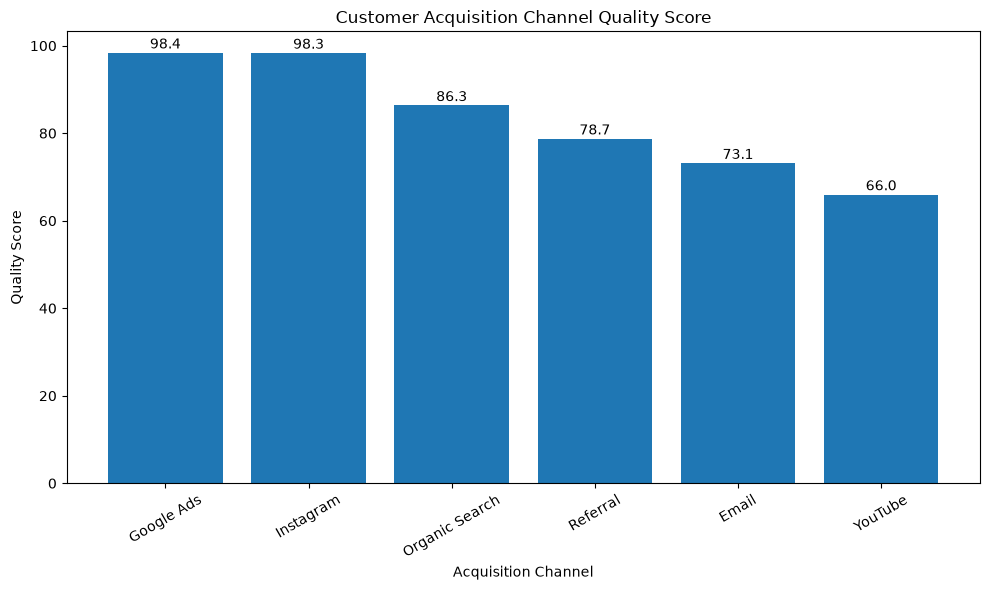

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    channel_score.index,
    channel_score["Acquisition_Quality_Score"]
)

plt.title("Customer Acquisition Channel Quality Score")
plt.xlabel("Acquisition Channel")
plt.ylabel("Quality Score")

plt.xticks(rotation=30)

for i, value in enumerate(
    channel_score["Acquisition_Quality_Score"]
):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [27]:
print("PRODUCTS COLUMNS:", products.columns.tolist())
print("Products Shape:", products.shape)

products.head()

NameError: name 'products' is not defined

In [28]:
import os

print(os.listdir())

['01_data_cleaning.ipynb', '02_eda.ipynb', '03_customer_analysis.ipynb', '04_sales_analysis.ipynb', '05_marketing_analysis.ipynb', '06_revenue_forecasting.ipynb']


In [29]:
import os

print(os.listdir("data"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data'